# This notebook includes fine-tuning

In [1]:
!pip install vmdpy optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 8.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from vmdpy import VMD
import optuna

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
## === Global Variables ===
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

WINDOW_SIZE = 60
# Default values; these will be tuned via optuna
NUM_NEURONS = 128
DROPOUT_RATE = 0.3
PATIENCE = 10
EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 0.001

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Ensure TensorFlow is using GPU
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"GPU Detected: {device_name}")
else:
    print("No GPU found. Training may be slow.")

GPU Detected: /device:GPU:0


In [6]:
### Load the data
data = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Bitcoin_data_2024.csv",
                   index_col=0, parse_dates=True)
data = data[['Close']]

# Ensure the data is univariate
if data.shape[1] != 1:
    raise ValueError("Data must be univariate with only 'Close' column.")

In [7]:
### Split the data
n = len(data)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)

train_data = data.iloc[:train_end]
val_data   = data.iloc[train_end:val_end]
test_data  = data.iloc[val_end:]

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (356554, 1)
Validation shape: (101872, 1)
Test shape: (50938, 1)


In [8]:
# Perform VMD on the unscaled 'Close'
alpha = 2000
tau = 0
K = 8  # Number of IMFs
DC = 0
init = 1
tol = 1e-7

train_close = train_data['Close'].values
u_train, _, _ = VMD(train_close, alpha, tau, K, DC, init, tol)

# Create DataFrame with training indices
vmd_train = pd.DataFrame(
    u_train.T,
    columns=[f'IMF_{i}' for i in range(8)],
    index=train_data.index
)

In [9]:
# Modified VMD application with proper boundary handling
def safe_vmd_decomposition(main_data, prev_data, window_size):
    """Apply VMD with boundary handling to prevent leakage"""
    extended_data = np.concatenate([prev_data[-window_size:], main_data])
    u, _, _ = VMD(extended_data, alpha=2000, tau=0, K=8, DC=0, init=1, tol=1e-7)
    return u[:, window_size:]  # Trim overlapping portion

# Apply VMD to training data (no previous data)
train_close = train_data['Close'].values
u_train, _, _ = VMD(train_close, alpha=2000, tau=0, K=8, DC=0, init=1, tol=1e-7)
vmd_train = pd.DataFrame(u_train.T, columns=[f'IMF_{i}' for i in range(8)], index=train_data.index)

# Apply VMD to validation data using training boundary
val_close = val_data['Close'].values
u_val = safe_vmd_decomposition(val_close, train_close, WINDOW_SIZE)
vmd_val = pd.DataFrame(u_val.T, columns=[f'IMF_{i}' for i in range(8)], index=val_data.index)

# Apply VMD to test data using validation boundary
test_close = test_data['Close'].values
u_test = safe_vmd_decomposition(test_close, val_close, WINDOW_SIZE)
vmd_test = pd.DataFrame(u_test.T, columns=[f'IMF_{i}' for i in range(8)], index=test_data.index)

In [10]:
# Initialize scalers using ONLY training data
scaler_imfs = {}
for i in range(8):
    scaler = MinMaxScaler()
    scaler.fit(vmd_train[[f'IMF_{i}']])  # Train on training IMFs only
    scaler_imfs[f'IMF_{i}'] = scaler

# Scale all sets using training scalers
def safe_scale(df, scaler_dict):
    scaled_df = df.copy()
    for imf in scaler_dict:
        scaled_df[imf] = scaler_dict[imf].transform(df[[imf]])
    return scaled_df

vmd_train = safe_scale(vmd_train, scaler_imfs)
vmd_val = safe_scale(vmd_val, scaler_imfs)
vmd_test = safe_scale(vmd_test, scaler_imfs)

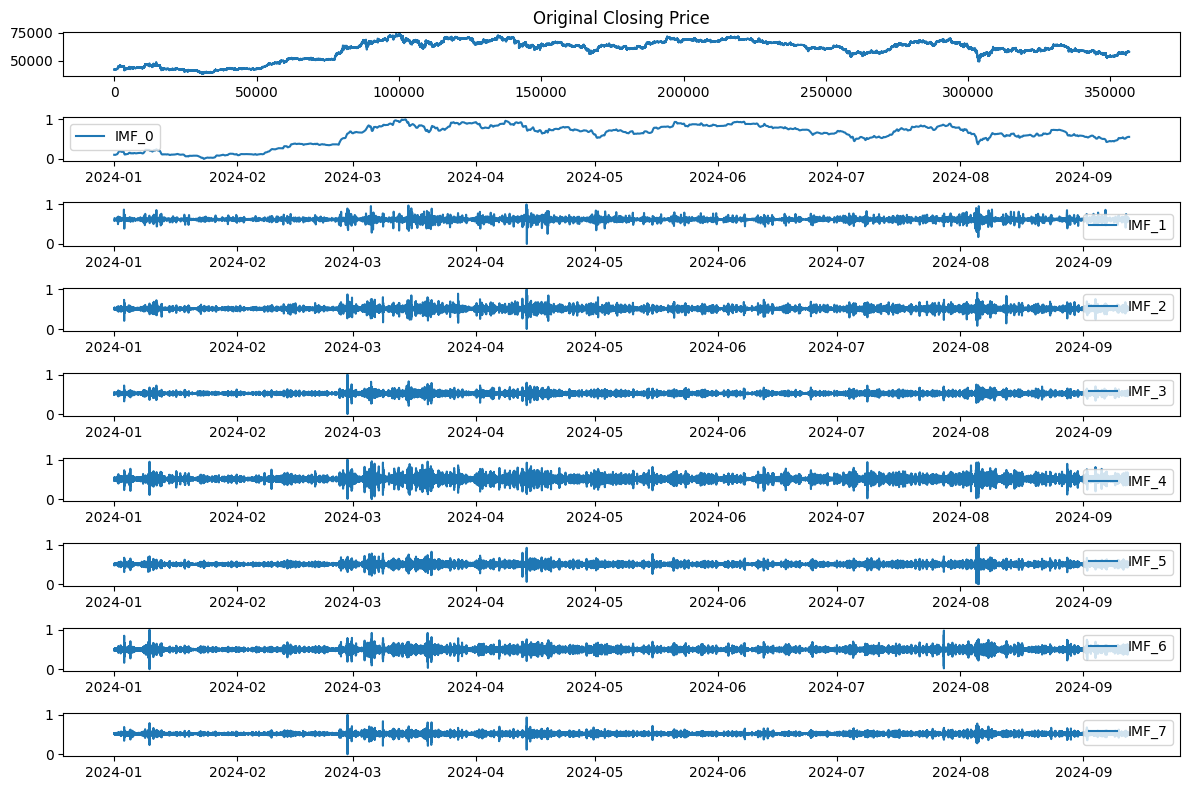

In [11]:
# Plot VMD decomposition for the training period
fig, axs = plt.subplots(K+1, 1, figsize=(12, 8))
axs[0].plot(train_data['Close'].values, label="Original Close Price")
axs[0].set_title("Original Closing Price")
for i in range(K):
    axs[i+1].plot(vmd_train[f'IMF_{i}'], label=f"IMF_{i}")
    axs[i+1].legend()
plt.tight_layout()
plt.show()

In [12]:
# Updated sequence creation with temporal safeguards
def create_leakproof_sequences(df, window_size):
    """Create sequences ensuring no future data contamination"""
    X, y = [], []
    for i in range(len(df) - window_size):
        X.append(df.iloc[i:i+window_size].values)
        y.append(df.iloc[i+window_size].values)
    return np.array(X), np.array(y)

# Create sequences for each IMF set
X_train, y_train = create_leakproof_sequences(vmd_train, WINDOW_SIZE)
X_val, y_val = create_leakproof_sequences(vmd_val, WINDOW_SIZE)
X_test, y_test = create_leakproof_sequences(vmd_test, WINDOW_SIZE)

# Reshape for GRU input (samples, timesteps, features)
X_train = X_train.transpose(0, 2, 1)
X_val = X_val.transpose(0, 2, 1)
X_test = X_test.transpose(0, 2, 1)

print("X_train shape:", X_train.shape)  # Expect (samples, K, WINDOW_SIZE)
print("y_train shape:", y_train.shape)

X_train shape: (356494, 8, 60)
y_train shape: (356494, 8)


In [13]:
### === Define the Attention-GRU Model with Hyperparameter Arguments ===
def build_attention_gru_model(input_shape, num_neurons, dropout_rate, learning_rate):
    """
    Build an Attention-GRU model with hyperparameters.
    input_shape: (timesteps, features) → here (WINDOW_SIZE, 1)
    """
    print(f"Building model with input shape: {input_shape}, num_neurons: {num_neurons}, dropout_rate: {dropout_rate}, learning_rate: {learning_rate}")
    inputs = Input(shape=input_shape)
    x = GRU(num_neurons, return_sequences=True)(inputs)
    # Using Keras's built-in attention layer (query=key=x)
    x = tf.keras.layers.Attention()([x, x])
    x = Dropout(dropout_rate)(x)
    x = Flatten()(x)
    output = Dense(1)(x)
    model = Model(inputs, output)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

In [14]:
### === Hyperparameter Tuning with Optuna ===
def objective(trial):
    # Suggest hyperparameters
    num_neurons = trial.suggest_int("num_neurons", 64, 256, step=32)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)

    # Build model with suggested hyperparameters
    model = build_attention_gru_model((WINDOW_SIZE, 1), num_neurons, dropout_rate, learning_rate)

    # Use early stopping to avoid overfitting during tuning
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

    # For tuning, we use the IMF_0 data (reshape to add channel dimension)
    history = model.fit(
        X_train[:, 0, :].reshape(-1, WINDOW_SIZE, 1),
        y_train[:, 0],
        validation_data=(X_val[:, 0, :].reshape(-1, WINDOW_SIZE, 1), y_val[:, 0]),
        epochs=20,  # Fewer epochs for faster tuning
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    # Return the best validation loss achieved during tuning
    val_loss = min(history.history['val_loss'])
    return val_loss

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
best_params = study.best_params
print("Best hyperparameters found:", best_params)

[I 2025-02-16 18:48:22,579] A new study created in memory with name: no-name-7e2c4aa0-5f65-4412-ae19-f28bc5ebcc81


Building model with input shape: (60, 1), num_neurons: 192, dropout_rate: 0.43855213578542396, learning_rate: 0.00017755175201614054


[I 2025-02-16 18:50:49,315] Trial 0 finished with value: 4.381718554213876e-06 and parameters: {'num_neurons': 192, 'dropout_rate': 0.43855213578542396, 'learning_rate': 0.00017755175201614054}. Best is trial 0 with value: 4.381718554213876e-06.


Building model with input shape: (60, 1), num_neurons: 128, dropout_rate: 0.2840142248813179, learning_rate: 0.0007992599594628801


[I 2025-02-16 18:53:20,472] Trial 1 finished with value: 4.33634158980567e-06 and parameters: {'num_neurons': 128, 'dropout_rate': 0.2840142248813179, 'learning_rate': 0.0007992599594628801}. Best is trial 1 with value: 4.33634158980567e-06.


...

Building model with input shape: (60, 1), num_neurons: 160, dropout_rate: 0.3233680617762758, learning_rate: 0.0012281755511863494


[I 2025-02-16 19:40:02,235] Trial 28 finished with value: 5.928611244598869e-06 and parameters: {'num_neurons': 160, 'dropout_rate': 0.3233680617762758, 'learning_rate': 0.0012281755511863494}. Best is trial 18 with value: 3.858743184537161e-06.


Building model with input shape: (60, 1), num_neurons: 192, dropout_rate: 0.44908457665365414, learning_rate: 0.0002263565009806823


[I 2025-02-16 19:42:49,844] Trial 29 finished with value: 4.12622057410772e-06 and parameters: {'num_neurons': 192, 'dropout_rate': 0.44908457665365414, 'learning_rate': 0.0002263565009806823}. Best is trial 18 with value: 3.858743184537161e-06.


Best hyperparameters found: {'num_neurons': 224, 'dropout_rate': 0.4377731918676693, 'learning_rate': 0.00028440093330906943}


In [15]:
### === Modified Model Training using the Best Hyperparameters ===
def train_imf_model(imf_index, X_train, y_train, X_val, y_val, num_neurons, dropout_rate, learning_rate):
    model = build_attention_gru_model((WINDOW_SIZE, 1), num_neurons, dropout_rate, learning_rate)
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='min'
    )

    history = model.fit(
        X_train[:, imf_index, :].reshape(-1, WINDOW_SIZE, 1),
        y_train[:, imf_index],
        validation_data=(X_val[:, imf_index, :].reshape(-1, WINDOW_SIZE, 1), y_val[:, imf_index]),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )
    return model, history

# Train models for each IMF using the best hyperparameters from optuna
models = []
for i in range(8):
    print(f"\nTraining model for IMF_{i}...")
    model, _ = train_imf_model(i, X_train, y_train, X_val, y_val,
                               num_neurons=best_params['num_neurons'],
                               dropout_rate=best_params['dropout_rate'],
                               learning_rate=best_params['learning_rate'])
    models.append(model)


Training model for IMF_0...
Building model with input shape: (60, 1), num_neurons: 224, dropout_rate: 0.4377731918676693, learning_rate: 0.00028440093330906943
Epoch 1/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0078 - val_loss: 2.7629e-05
Epoch 2/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 2.2903e-04 - val_loss: 9.2575e-05
Epoch 3/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1.2569e-04 - val_loss: 2.0741e-05
Epoch 4/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 8.9729e-05 - val_loss: 6.7004e-06
Epoch 5/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 6.6074e-05 - val_loss: 8.6925e-06
Epoch 6/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5.3414e-05 - val_loss: 7.1303e-06
Epoch 7/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 4.4657e-05 - val_loss: 1.1201e-05
Epoch 8/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 3.7513e-05 - val_loss: 8.9886e-06
Epoch 9/100
1393/1393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 3.4

In [16]:
import joblib

# Save the scalers dictionary
scaler_save_path = "/content/drive/My Drive/Colab Notebooks/6.0/models/scaler_imfs.pkl"
joblib.dump(scaler_imfs, scaler_save_path)
print("Scalers saved successfully to", scaler_save_path)

# Save each model
for i, model in enumerate(models):
    model_save_path = f"/content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_{i}.keras"
    model.save(model_save_path)
    print(f"Model for IMF_{i} saved successfully to {model_save_path}")

# Save decomposed IMF data
vmd_train.to_csv("/content/drive/My Drive/Colab Notebooks/6.0/models/vmd_train.csv")
vmd_val.to_csv("/content/drive/My Drive/Colab Notebooks/6.0/models/vmd_val.csv")
vmd_test.to_csv("/content/drive/My Drive/Colab Notebooks/6.0/models/vmd_test.csv")
print("IMF CSV files saved successfully!")

# Save ground truth labels
np.save("/content/drive/My Drive/Colab Notebooks/6.0/models/y_val.npy", y_val)
np.save("/content/drive/My Drive/Colab Notebooks/6.0/models/y_test.npy", y_test)

# Save evaluation features
np.save("/content/drive/My Drive/Colab Notebooks/6.0/models/X_val.npy", X_val)
np.save("/content/drive/My Drive/Colab Notebooks/6.0/models/X_test.npy", X_test)

print("NumPy arrays for features and labels saved successfully!")

Scalers saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/scaler_imfs.pkl
Model for IMF_0 saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_0.keras
Model for IMF_1 saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_1.keras
Model for IMF_2 saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_2.keras
Model for IMF_3 saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_3.keras
Model for IMF_4 saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_4.keras
Model for IMF_5 saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_5.keras
Model for IMF_6 saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_6.keras
Model for IMF_7 saved successfully to /content/drive/My Drive/Colab Notebooks/6.0/models/model_imf_7.keras
IMF CSV files saved successfully!
NumPy arrays 

## Evaluation
### Val set evaluation

In [17]:
def safe_predict(models, X_set, scalers):
    """Make predictions without data leakage"""
    pred_imfs = []
    for i, model in enumerate(models):
        pred = model.predict(X_set[:, i, :])
        pred_imfs.append(scalers[f'IMF_{i}'].inverse_transform(pred))
    return np.sum(pred_imfs, axis=0)

# Generate final predictions
y_val_pred = safe_predict(models, X_val, scaler_imfs)
y_test_pred = safe_predict(models, X_test, scaler_imfs)

# Get actual values with proper window offset
actual_val = val_data['Close'].values[WINDOW_SIZE:]
actual_test = test_data['Close'].values[WINDOW_SIZE:]

3182/3182 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3182/3182 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
3182/3182 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3182/3182 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3182/3182 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3182/3182 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3182/3182 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3182/3182 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1590/1590 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [18]:
### Evaluate on Validation Set ###

# Error metrics
mae_val = mean_absolute_error(actual_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(actual_val, y_val_pred))
mape_val = mean_absolute_percentage_error(actual_val, y_val_pred) * 100

print("Validation Set Metrics:")
print(f"MAE:  {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"MAPE: {mape_val:.2f}%\n")

Validation Set Metrics:
MAE:  69.5863
RMSE: 92.3110
MAPE: 0.10%



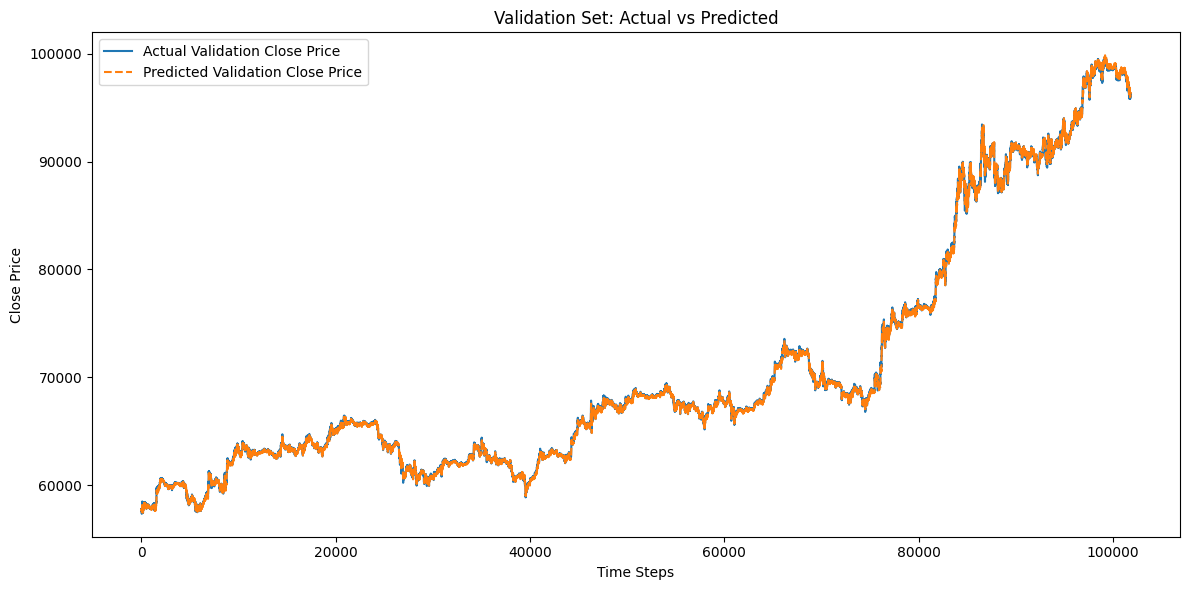

In [19]:
# Plot Predicted vs Actual for Validation Set
plt.figure(figsize=(12, 6))
plt.plot(actual_val, label='Actual Validation Close Price')
plt.plot(y_val_pred, label='Predicted Validation Close Price', linestyle='--')
plt.title('Validation Set: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

### Test set evaluation

In [20]:
### Evaluate on Test Set ###

# Error metrics
mae_test = mean_absolute_error(actual_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(actual_test, y_test_pred))
mape_test = mean_absolute_percentage_error(actual_test, y_test_pred) * 100

print("Test Set Metrics:")
print(f"MAE:  {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAPE: {mape_test:.2f}%\n")

Test Set Metrics:
MAE:  146.4056
RMSE: 184.0781
MAPE: 0.15%



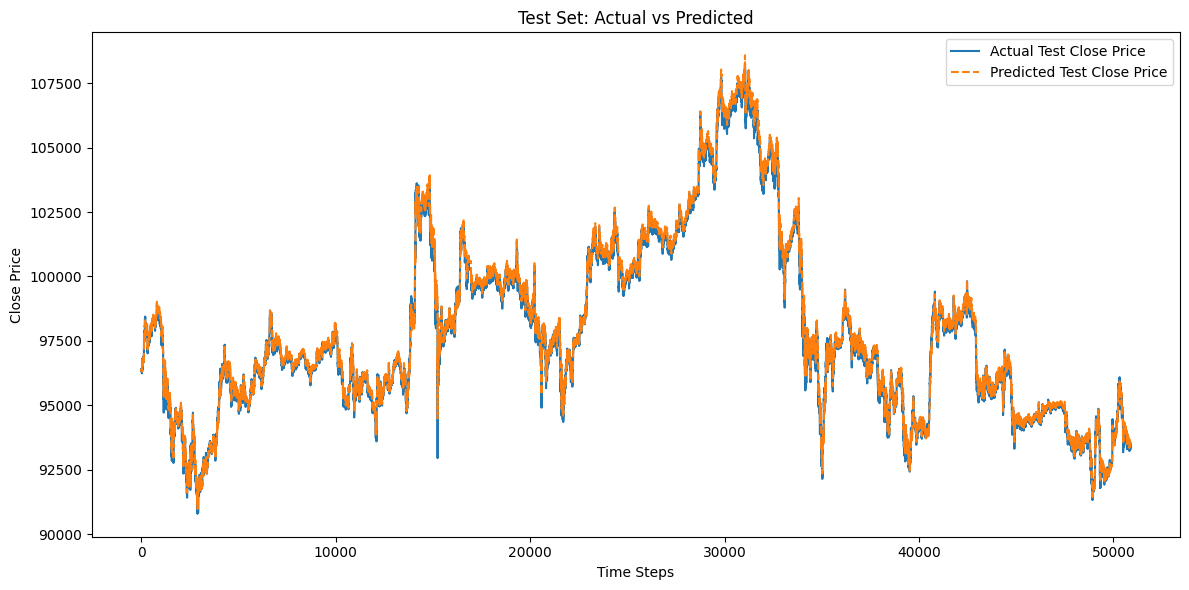

In [21]:
# Plot Predicted vs Actual for Test Set
plt.figure(figsize=(12, 6))
plt.plot(actual_test, label='Actual Test Close Price')
plt.plot(y_test_pred, label='Predicted Test Close Price', linestyle='--')
plt.title('Test Set: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
!nvidia-smi

Sun Feb 16 21:11:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             49W /  400W |     999MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----